In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import time
import xgboost as xgb
from catboost import CatBoostClassifier

In [2]:
train = pd.read_csv('/kaggle/input/competitions/porto-seguro-safe-driver-prediction/train.csv')
test = pd.read_csv('/kaggle/input/competitions/porto-seguro-safe-driver-prediction/test.csv')

In [3]:
train.replace(-1, np.nan, inplace=True)
test.replace(-1, np.nan, inplace=True)

In [4]:
y = train['target']
X = train.drop(['id', 'target'], axis=1)
test_features = test.drop(['id'], axis=1)

cv_folds = 5
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_features))

model = lgb.LGBMClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1,
    random_state=42, 
    verbosity=-1, 
    force_col_wise=True
)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    oof_preds[val_idx] = model.predict_proba(X_val_fold)[:, 1]
    
    test_preds += model.predict_proba(test_features)[:, 1] / cv_folds
    
    fold_auc = roc_auc_score(y_val_fold, oof_preds[val_idx])


cv_auc = roc_auc_score(y, oof_preds)
cv_gini = 2 * cv_auc - 1 

print(f"ROC-AUC: {cv_auc:.5f}")
print(f"GINI: {cv_gini:.5f}")


ROC-AUC: 0.63887
GINI: 0.27773


**Проведём EDA, найдём матрицу корреляций:**

ps_car_13        0.053899
ps_car_12        0.038800
ps_ind_17_bin    0.037053
ps_reg_02        0.034800
ps_ind_07_bin    0.034218
Name: target, dtype: float64

Топ-5 бесполезных признаков:
ps_calc_04        0.000033
ps_calc_06        0.000082
ps_calc_07       -0.000103
ps_calc_17_bin   -0.000170
id               -0.000188
Name: target, dtype: float64


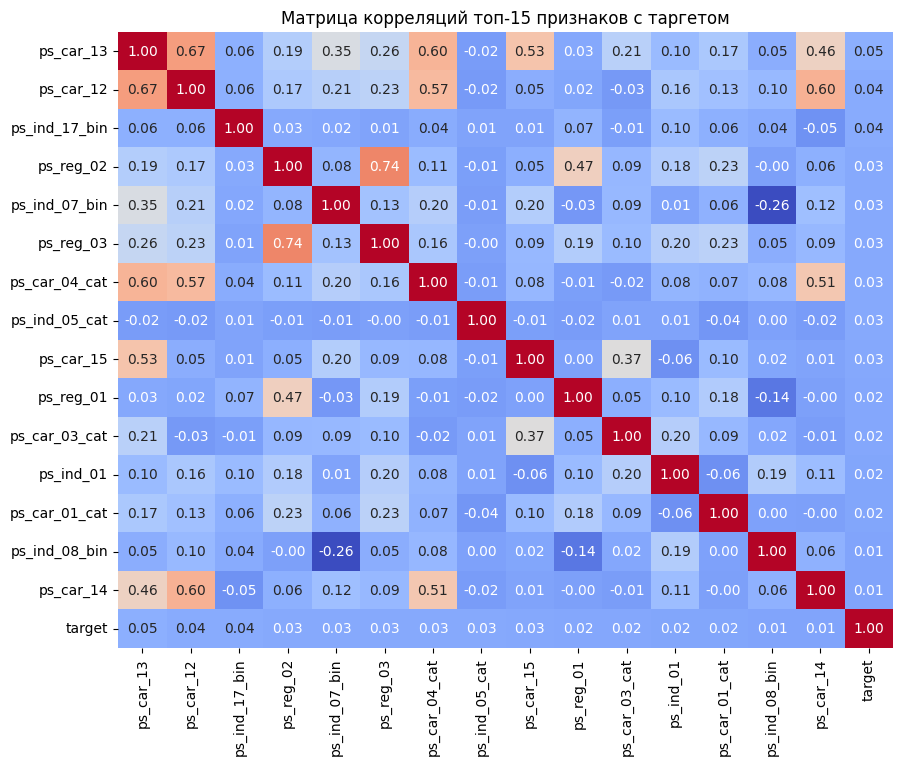

In [5]:
correlations = train.corr()['target'].sort_values(ascending=False)

print(correlations[1:6])

print("\nТоп-5 бесполезных признаков:")
print(correlations.iloc[correlations.abs().argsort()][:5])

top_features = correlations[1:16].index.tolist()
top_features.append('target')

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.title('Матрица корреляций топ-15 признаков с таргетом')
plt.show()

**ВЫВОД:**
1. признаки pc_calc бесполезны
2. ps_reg_02 и ps_reg_03, а также ps_car_12 и ps_car_13 можно объединить, перемножив друг на друга
3. target почти никак не коррилиурует => можно сделать вывод, что нам не подойдут линейные модели(скорее всего подойдут деревья)

In [6]:
X_fe = X.copy()
test_fe = test_features.copy()

X_fe['missing_count'] = X.isnull().sum(axis=1)
test_fe['missing_count'] = test_features.isnull().sum(axis=1)

calc_cols = [col for col in X_fe.columns if 'calc' in col]
X_fe.drop(calc_cols, axis=1, inplace=True)
test_fe.drop(calc_cols, axis=1, inplace=True)

print("\nОбучаем LightGBM")
oof_preds_fe = np.zeros(len(X_fe))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_fe, y)):
    X_train_fold, y_train_fold = X_fe.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X_fe.iloc[val_idx], y.iloc[val_idx]
    
    model_fe = lgb.LGBMClassifier(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1,
        random_state=42, 
        verbosity=-1, 
        force_col_wise=True
    )
    
    model_fe.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    oof_preds_fe[val_idx] = model_fe.predict_proba(X_val_fold)[:, 1]

cv_auc_fe = roc_auc_score(y, oof_preds_fe)
cv_gini_fe = 2 * cv_auc_fe - 1

print(f"GINI: {cv_gini_fe:.5f}")



Обучаем LightGBM
GINI: 0.27864


**получили более низкий gini(о.26119), делаем вывод, что перемножение признаков не помогло:**

    X_fe['reg_02_x_reg_03'] = X_fe['ps_reg_02'] * X_fe['ps_reg_03']


    test_fe['reg_02_x_reg_03'] = test_fe['ps_reg_02'] * test_fe['ps_reg_03']



    X_fe['car_12_x_car_13'] = X_fe['ps_car_12'] * X_fe['ps_car_13']

    test_fe['car_12_x_car_13'] = test_fe['ps_car_12'] * test_fe['ps_car_13']


    cat_cols = [col for col in X_fe.columns if '_cat' in col]

    for col in cat_cols:

        X_fe[col] = X_fe[col].astype('category')
    
        test_fe[col] = test_fe[col].astype('category')
    

**без перемножений результат немного улучшился(0.27864)**


In [ ]:
models = {
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, 
        max_depth=6, 
        learning_rate=0.05,
        random_state=42, 
        verbosity=-1, 
        force_col_wise=True
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, 
        max_depth=6, 
        learning_rate=0.05, 
        random_state=42, 
        eval_metric='logloss', 
        verbosity=0
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, 
        depth=6, 
        learning_rate=0.05,
        random_state=42, 
        verbose=False
    )
}

oof_predictions = {}
test_predictions = {}

for name, model in models.items():
    start_time = time.time()
    print(f"Обучается {name}...")
    
    oof_preds = np.zeros(len(X_fe))
    test_preds = np.zeros(len(test_fe))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_fe, y)):
        X_tr, y_tr = X_fe.iloc[train_idx], y.iloc[train_idx]
        X_va, y_val = X_fe.iloc[val_idx], y.iloc[val_idx]

        if name == 'LightGBM':
            model.fit(
                X_tr, y_tr, 
                eval_set=[(X_va, y_val)], 
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
            )
        elif name == 'CatBoost':
            model.fit(
                X_tr, y_tr, 
                eval_set=[(X_va, y_val)], 
                early_stopping_rounds=50, 
                verbose=False
            )
        else: #XGBoost
            model.fit(
                X_tr, y_tr, 
                eval_set=[(X_va, y_val)], 
                verbose=False
            )

        oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
        test_preds += model.predict_proba(test_fe)[:, 1] / cv_folds

    model_auc = roc_auc_score(y, oof_preds)
    model_gini = 2 * model_auc - 1
    
    oof_predictions[name] = oof_preds
    test_predictions[name] = test_preds
    
    elapsed = time.time() - start_time
    print(f"[{name}] Завершено за {elapsed:.1f} сек. | Итоговый CV Gini: {model_gini:.5f}\n")


Обучается LightGBM...
[LightGBM] Завершено за 98.2 сек. | Итоговый CV Gini: 0.28186

Обучается XGBoost...
[XGBoost] Завершено за 153.4 сек. | Итоговый CV Gini: 0.27721

Обучается CatBoost...
[CatBoost] Завершено за 107.1 сек. | Итоговый CV Gini: 0.28148

Все модели успешно обучены! Данные собраны для финального блендинга.


In [8]:
from scipy.optimize import minimize

oof_lgb = oof_predictions['LightGBM']
oof_xgb = oof_predictions['XGBoost']
oof_cb = oof_predictions['CatBoost']

test_lgb = test_predictions['LightGBM']
test_xgb = test_predictions['XGBoost']
test_cb = test_predictions['CatBoost']

def roc_auc_objective(weights):
    blended_oof = (weights[0] * oof_lgb + 
                   weights[1] * oof_xgb + 
                   weights[2] * oof_cb)
    return -roc_auc_score(y, blended_oof)

init_weights = [1/3, 1/3, 1/3]

bounds = [(0, 1), (0, 1), (0, 1)]

constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})

res = minimize(
    roc_auc_objective, 
    init_weights, 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

best_weights = res.x

print("\nОптимальные веса:")
print(f"LightGBM: {best_weights[0]:.4f}")
print(f"XGBoost:  {best_weights[1]:.4f}")
print(f"CatBoost: {best_weights[2]:.4f}")

final_oof = (best_weights[0] * oof_lgb + 
             best_weights[1] * oof_xgb + 
             best_weights[2] * oof_cb)
             
final_auc = roc_auc_score(y, final_oof)
final_gini = 2 * final_auc - 1

print(f"GINI: {final_gini:.5f}")

final_test_preds = (best_weights[0] * test_lgb + 
                    best_weights[1] * test_xgb + 
                    best_weights[2] * test_cb)

submission = pd.DataFrame({'id': test['id'], 'target': final_test_preds})
submission.to_csv('submission.csv', index=False)


Оптимальные веса:
LightGBM: 0.3333
XGBoost:  0.3333
CatBoost: 0.3333
GINI: 0.28521
